In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-dataset/Student_Performance_Dataset.csv


In [2]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/kaggle/input/student-performance-dataset/Student_Performance_Dataset.csv")
print(df.head(10))

  Student_ID  Age  Gender  Class  Study_Hours_Per_Day  Attendance_Percentage  \
0      S0001   15    Male     12                  1.0                     65   
1      S0002   19  Female      9                  1.6                     58   
2      S0003   14  Female     12                  3.6                     64   
3      S0004   18  Female      9                  5.5                     68   
4      S0005   14    Male     10                  5.0                     80   
5      S0006   19    Male     12                  5.2                     82   
6      S0007   16    Male     12                  0.8                     78   
7      S0008   18  Female     11                  2.0                     81   
8      S0009   18  Female     11                  3.5                     61   
9      S0010   18    Male     10                  5.7                     97   

  Parental_Education Internet_Access Extracurricular_Activities  Math_Score  \
0       Postgraduate              No    

In [8]:
count_english_above_90 = (df["English_Score"] > 90).sum()
print("Students scoring above 90 in english:", count_english_above_90)

Students scoring above 90 in english: 811


In [9]:
avg_science_female = df[df["Gender"] == "Female"]["Science_Score"].mean()
print("Average science score of female students:", avg_science_female)

Average science score of female students: 66.91069330199765


In [12]:
# Create Final Percentage categories
bins = [0, 50, 70, 85, 100]
labels = ["Low", "Average", "Good", "Excellent"]

df["Final_Percentage_Category"] = pd.cut(df["Final_Percentage"],
                                         bins=bins,
                                         labels=labels)
# Group by category and calculate average math score
avg_math_by_final = df.groupby("Final_Percentage_Category")["Math_Score"].mean()
print(avg_math_by_final)

Final_Percentage_Category
Low          46.442105
Average      62.367868
Good         76.119128
Excellent    88.551331
Name: Math_Score, dtype: float64


/tmp/ipykernel_55/881874547.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_math_by_final = df.groupby("Final_Percentage_Category")["Math_Score"].mean()


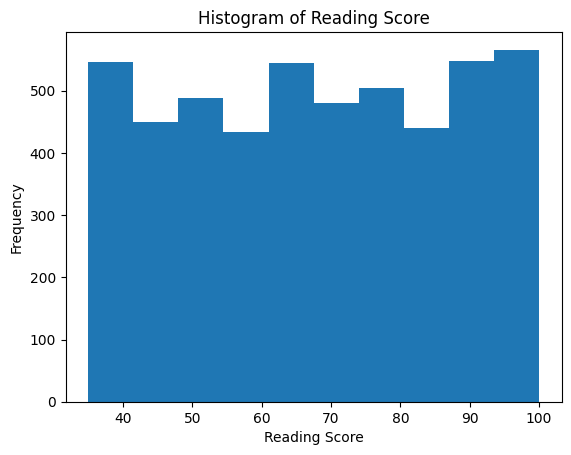

In [13]:
plt.hist(df["English_Score"])
plt.xlabel("Reading Score")
plt.ylabel("Frequency")
plt.title("Histogram of Reading Score")
plt.show()


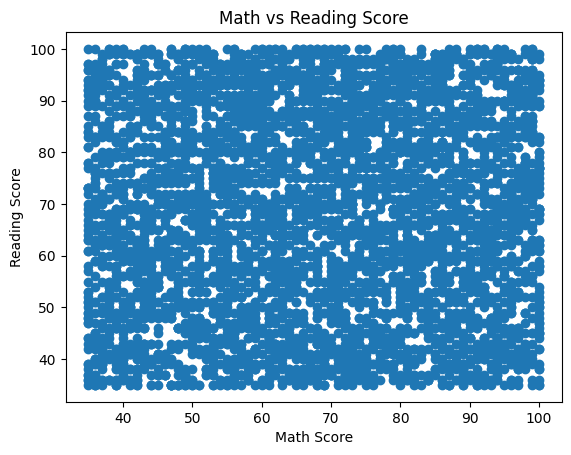

In [14]:
plt.scatter(df["Math_Score"], df["English_Score"])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Score")
plt.show()


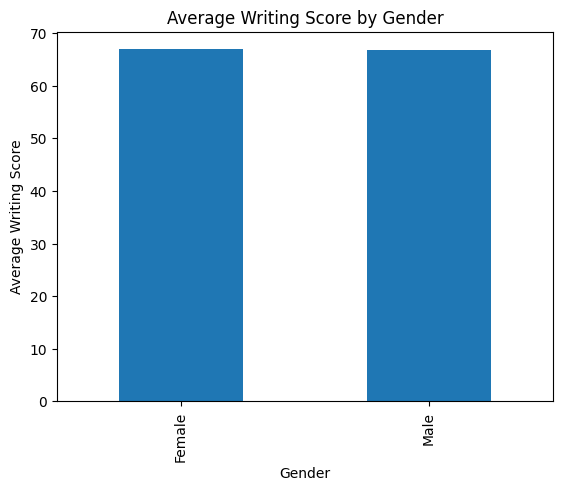

In [15]:
avg_writing_gender = df.groupby("Gender")["Science_Score"].mean()
avg_writing_gender.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Average Writing Score")
plt.title("Average Writing Score by Gender")
plt.show()


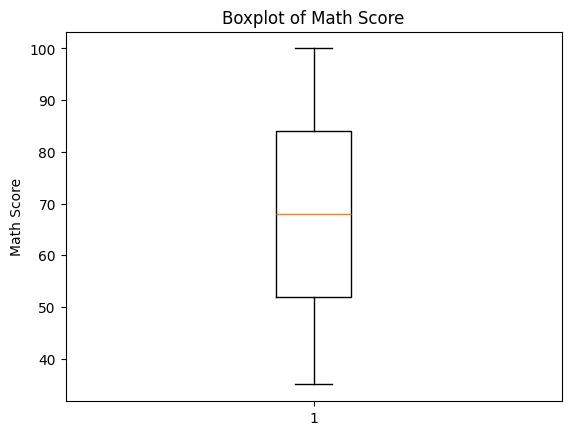

In [16]:
plt.boxplot(df["Math_Score"])
plt.ylabel("Math Score")
plt.title("Boxplot of Math Score")
plt.show()


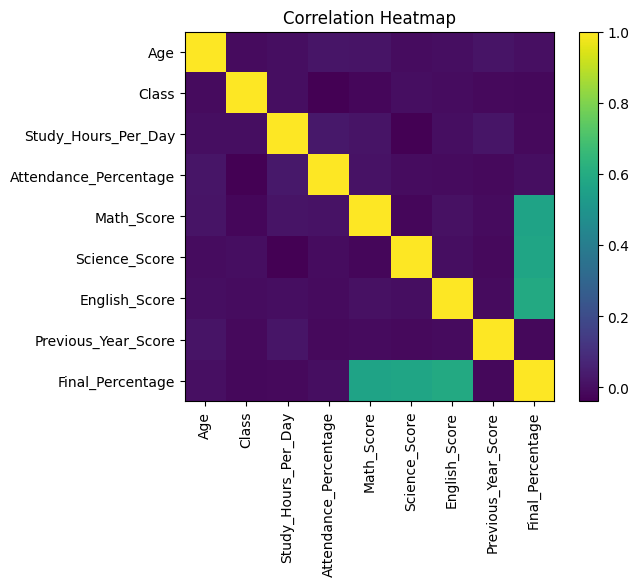

In [17]:
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df_sorted = df.sort_values(by="English_Score", ascending=True)
print(df_sorted.head())

     Student_ID  Age  Gender  Class  Study_Hours_Per_Day  \
4967      S4968   14  Female     10                  5.0   
3015      S3016   15  Female     11                  5.5   
3377      S3378   16  Female     11                  1.3   
4763      S4764   16    Male     11                  0.8   
841       S0842   17    Male     12                  5.4   

      Attendance_Percentage Parental_Education Internet_Access  \
4967                     56           Graduate              No   
3015                     78        High School              No   
3377                     63           Graduate             Yes   
4763                     50       Postgraduate              No   
841                      99           Graduate              No   

     Extracurricular_Activities  Math_Score  Science_Score  English_Score  \
4967                         No          37             50             35   
3015                         No          69             55             35   
3377       

In [19]:
high_writing_students = df[df["Science_Score"] > 95]
high_writing_students.to_csv("high_writing_students.csv", index=False)
print("File saved successfully!")

File saved successfully!
